<a href="https://colab.research.google.com/github/Akuro02/Projeto-IA--Simulacao-de-Opiniao-Publica/blob/main/Copy_of_simulacao_opiniao_publica_cesop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulação de Opinião Pública com LLMs
## Pesquisa CESOP – Racismo Ambiental e Representação Étnico-Racial

**Questões simuladas:**
- **P12** – Conhecimento sobre *racismo ambiental* (RU: Sim/Não)
- **P20** – Espaços onde o grupo étnico-racial se sente representado (RM, múltipla escolha)
- **P25** – Conhecimento sobre *equidade* (RU: Sim/Não)

**Referência metodológica:** Miranda, F.; Balbi, P.P. *Simulating Public Opinion: Comparing Distributional and Individual-Level Predictions from LLMs and Random Forests.* Entropy 2025, 27, 923.

---
> **Execução 100% gratuita e aberta** – usa modelos `google/flan-t5-large` e `mistralai/Mistral-7B-Instruct-v0.2` via HuggingFace (sem API key privada). Pode ser executado no Google Colab.


## 0. Instalação de Dependências

In [ ]:
# ============================================================
# Instalar dependências necessárias
# ============================================================
!pip install -q transformers accelerate sentencepiece scikit-learn pandas numpy matplotlib seaborn scipy tqdm
print('✓ Dependências instaladas')

✓ Dependências instaladas


## 1. Importações e Configurações Globais

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy.spatial.distance import jensenshannon
from scipy.stats import chi2_contingency
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import random
import json
import re
import warnings
warnings.filterwarnings('ignore')

# Semente global para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Configuração de visualização
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')

print('✓ Configurações carregadas')

✓ Configurações carregadas


## 2. Dados Empíricos da Pesquisa CESOP

Distribuições reais extraídas das tabelas SPSS fornecidas na pesquisa.

In [ ]:
# ============================================================
# Distribuições empíricas reais (N=2000)
# ============================================================

# P12 – Conhecimento sobre racismo ambiental (RU)
P12_EMPIRICO = {
    'Sim':  486 / 2000,   # 24.3%
    'Não': 1514 / 2000,   # 75.7%
}

# P20 – Espaços de representação adequada do grupo étnico-racial (RM, múltipla)
# Frequências relativas ao total de respondentes (N=2000)
P20_EMPIRICO = {
    'Política':                         579 / 2000,
    'Poder Executivo':                  150 / 2000,
    'Poder Legislativo':                 68 / 2000,
    'Poder Judiciário':                  60 / 2000,
    'Organismos Internacionais':         67 / 2000,
    'Mídia':                            233 / 2000,
    'Setor Empresarial':                 49 / 2000,
    'Movimentos Sociais':               131 / 2000,
    'ONGs':                              49 / 2000,
    'Não se sente representado':        354 / 2000,
    'Não sabe / Não respondeu':         260 / 2000,
}

# P25 – Conhecimento sobre equidade (RU)
P25_EMPIRICO = {
    'Sim':  539 / 2000,   # 27.0%
    'Não': 1461 / 2000,   # 73.1%  (total arredondado)
}

# Exibir resumo
print('=== Distribuições Empíricas (N=2000) ===')
print('\n[P12] Racismo Ambiental')
for k, v in P12_EMPIRICO.items():
    print(f'  {k}: {v*100:.1f}%')
print('\n[P20] Representação Étnico-Racial (RM)')
for k, v in P20_EMPIRICO.items():
    print(f'  {k}: {v*100:.1f}%')
print('\n[P25] Equidade')
for k, v in P25_EMPIRICO.items():
    print(f'  {k}: {v*100:.1f}%')

=== Distribuições Empíricas (N=2000) ===

[P12] Racismo Ambiental
  Sim: 24.3%
  Não: 75.7%

[P20] Representação Étnico-Racial (RM)
  Política: 28.9%
  Poder Executivo: 7.5%
  Poder Legislativo: 3.4%
  Poder Judiciário: 3.0%
  Organismos Internacionais: 3.4%
  Mídia: 11.7%
  Setor Empresarial: 2.5%
  Movimentos Sociais: 6.6%
  ONGs: 2.5%
  Não se sente representado: 17.7%
  Não sabe / Não respondeu: 13.0%

[P25] Equidade
  Sim: 27.0%
  Não: 73.0%


## 3. Perfis Sintéticos de Respondentes

Geramos perfis demográficos baseados em características típicas da pesquisa CESOP sobre racismo e identidade étnico-racial no Brasil.

In [ ]:
# ============================================================
# Gerador de perfis demográficos sintéticos brasileiros
# ============================================================

REGIOES    = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']
PESOS_REG  = [0.08, 0.27, 0.08, 0.43, 0.14]   # proporcional ao IBGE

RACAS      = ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena']
PESOS_RACA = [0.43, 0.11, 0.43, 0.02, 0.01]   # PNAD Contínua 2022

ESCOLARIDADES = [
    'Sem instrução / fundamental incompleto',
    'Fundamental completo / médio incompleto',
    'Médio completo / superior incompleto',
    'Superior completo ou mais'
]
PESOS_ESC = [0.36, 0.23, 0.28, 0.13]

RENDAS = [
    'Até 1 salário mínimo',
    'De 1 a 3 salários mínimos',
    'De 3 a 5 salários mínimos',
    'Acima de 5 salários mínimos'
]
PESOS_RENDA = [0.32, 0.40, 0.17, 0.11]

SEXOS = ['Masculino', 'Feminino']
PESOS_SEXO = [0.48, 0.52]

IDADES_FAIXAS = ['18-24', '25-34', '35-44', '45-59', '60+']
PESOS_IDADE   = [0.14, 0.22, 0.20, 0.25, 0.19]


def gerar_perfil(rng: np.random.Generator) -> dict:
    """Retorna um dicionário com características demográficas de um respondente."""
    return {
        'regiao':       rng.choice(REGIOES,       p=PESOS_REG),
        'raca_cor':     rng.choice(RACAS,         p=PESOS_RACA),
        'escolaridade': rng.choice(ESCOLARIDADES, p=PESOS_ESC),
        'renda':        rng.choice(RENDAS,        p=PESOS_RENDA),
        'sexo':         rng.choice(SEXOS,         p=PESOS_SEXO),
        'faixa_etaria': rng.choice(IDADES_FAIXAS, p=PESOS_IDADE),
    }


def gerar_amostra(n: int, seed: int) -> list[dict]:
    rng = np.random.default_rng(seed)
    return [gerar_perfil(rng) for _ in range(n)]


# Pré-visualização
amostra_exemplo = gerar_amostra(5, seed=0)
pd.DataFrame(amostra_exemplo)

,regiao,raca_cor,escolaridade,renda,sexo,faixa_etaria
0,Sudeste,Branca,Sem instrução / fundamental incompleto,Até 1 salário mínimo,Feminino,60+
1,Sudeste,Parda,Fundamental completo / médio incompleto,Acima de 5 salários mínimos,Feminino,18-24
2,Sudeste,Branca,Médio completo / superior incompleto,Até 1 salário mínimo,Feminino,35-44
3,Nordeste,Branca,Sem instrução / fundamental incompleto,Até 1 salário mínimo,Feminino,45-59
4,Sudeste,Branca,Superior completo ou mais,Acima de 5 salários mínimos,Feminino,45-59


## 4. Carregamento do Modelo LLM

Usamos **`google/flan-t5-large`** (770M parâmetros) – modelo de texto-para-texto aberto, gratuito e executável no Colab CPU/T4.  
Para maior acurácia, substitua por `mistralai/Mistral-7B-Instruct-v0.2` (requer GPU T4/A100).

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, AutoModelForCausalLM, pipeline

# ============================================================
# Seleção automática de modelo conforme hardware disponível
# ============================================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {DEVICE}')

# Modelo padrão (CPU-compatível): flan-t5-large
# Para GPU T4 ou superior, descomente Mistral abaixo
USE_MISTRAL = False  # altere para True se tiver GPU ≥ 12 GB VRAM

if USE_MISTRAL and DEVICE == 'cuda':
    MODEL_ID = 'mistralai/Mistral-7B-Instruct-v0.2'
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map='auto'
    )
    MODEL_TYPE = 'causal'
    print(f'✓ {MODEL_ID} carregado (causal LM)')
else:
    MODEL_ID = 'google/flan-t5-large'
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_ID).to(DEVICE)
    MODEL_TYPE = 'seq2seq'
    print(f'✓ {MODEL_ID} carregado (seq2seq)')

model.eval()
print(f'Parâmetros: {sum(p.numel() for p in model.parameters()):,}')

Dispositivo: cpu


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✓ google/flan-t5-large carregado (seq2seq)
Parâmetros: 783,150,080


## 5. Construção dos Prompts

Seguindo a abordagem de Miranda & Balbi (2025): prompts condicionados ao perfil demográfico do respondente sintético, em português, com instrução de resposta estruturada.

In [ ]:
# ============================================================
# Templates de prompts por questão
# ============================================================

SYSTEM_CONTEXT = (
    "Você simula as respostas de um(a) cidadão(ã) brasileiro(a) a um questionário "
    "de pesquisa de opinião pública realizado pelo CESOP/Unicamp sobre raça, "
    "identidade étnico-racial e desigualdades sociais no Brasil.\n"
    "Responda EXCLUSIVAMENTE com a opção indicada – sem explicações adicionais.\n\n"
)


def perfil_texto(p: dict) -> str:
    return (
        f"Perfil do(a) respondente: {p['sexo']}, {p['faixa_etaria']} anos, "
        f"raça/cor {p['raca_cor']}, escolaridade: {p['escolaridade']}, "
        f"renda: {p['renda']}, região: {p['regiao']}."
    )


def prompt_p12(perfil: dict) -> str:
    return (
        f"A Brazilian survey respondent: {perfil['sexo']}, age {perfil['faixa_etaria']}, "
        f"race {perfil['raca_cor']}, education: {perfil['escolaridade']}, "
        f"income: {perfil['renda']}, region: {perfil['regiao']}.\n"
        f"Question: Has this person ever heard of 'environmental racism' (racismo ambiental)?\n"
        f"Answer with only the number: 1 for Yes, 2 for No."
    )

def prompt_p25(perfil: dict) -> str:
    return (
        f"A Brazilian survey respondent: {perfil['sexo']}, age {perfil['faixa_etaria']}, "
        f"race {perfil['raca_cor']}, education: {perfil['escolaridade']}, "
        f"income: {perfil['renda']}, region: {perfil['regiao']}.\n"
        f"Question: Has this person ever heard of the concept of 'equity' (equidade)?\n"
        f"Answer with only the number: 1 for Yes, 2 for No."
    )

def prompt_p20(perfil: dict) -> str:
    return (
        f"A Brazilian survey respondent: {perfil['sexo']}, age {perfil['faixa_etaria']}, "
        f"race {perfil['raca_cor']}, education: {perfil['escolaridade']}, "
        f"income: {perfil['renda']}, region: {perfil['regiao']}.\n"
        f"Question: In which spaces does this person feel their ethnic-racial group is adequately represented?\n"
        f"Options: 1-Politics, 2-Executive Power, 3-Legislative Power, 4-Judiciary, "
        f"5-International Organizations, 6-Media, 7-Business, 8-Social Movements, 9-NGOs, "
        f"97-Not represented anywhere, 99-Does not know.\n"
        f"Answer with numbers separated by commas, or just 97 or 99."
    )


# Teste dos prompts
p_teste = gerar_amostra(1, seed=123)[0]
print('[Perfil teste]\n', json.dumps(p_teste, ensure_ascii=False, indent=2))
print('\n[Prompt P12]\n', prompt_p12(p_teste))
print('\n[Prompt P20]\n', prompt_p20(p_teste))
print('\n[Prompt P25]\n', prompt_p25(p_teste))

[Perfil teste]
 {
  "regiao": "Sudeste",
  "raca_cor": "Branca",
  "escolaridade": "Sem instrução / fundamental incompleto",
  "renda": "Até 1 salário mínimo",
  "sexo": "Masculino",
  "faixa_etaria": "60+"
}

[Prompt P12]
 A Brazilian survey respondent: Masculino, age 60+, race Branca, education: Sem instrução / fundamental incompleto, income: Até 1 salário mínimo, region: Sudeste.
Question: Has this person ever heard of 'environmental racism' (racismo ambiental)?
Answer with only the number: 1 for Yes, 2 for No.

[Prompt P20]
 A Brazilian survey respondent: Masculino, age 60+, race Branca, education: Sem instrução / fundamental incompleto, income: Até 1 salário mínimo, region: Sudeste.
Question: In which spaces does this person feel their ethnic-racial group is adequately represented?
Options: 1-Politics, 2-Executive Power, 3-Legislative Power, 4-Judiciary, 5-International Organizations, 6-Media, 7-Business, 8-Social Movements, 9-NGOs, 97-Not represented anywhere, 99-Does not know.
A

## 6. Inferência com o LLM e Parsing de Respostas

In [ ]:
# ============================================================
# Funções de inferência e parsing
# ============================================================

def gerar_resposta_llm(prompt: str, max_new_tokens: int = 40) -> str:
    """Gera texto usando o modelo carregado."""
    inputs = tokenizer(prompt, return_tensors='pt', truncation=True,
                       max_length=512).to(DEVICE)
    with torch.no_grad():
        if MODEL_TYPE == 'seq2seq':
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=1.5
            )
        else:  # causal
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=0.3,
                top_p=0.9,
                pad_token_id=tokenizer.eos_token_id
            )
    # Para causal, remover o prompt do output
    if MODEL_TYPE == 'causal':
        gen_ids = outputs[0][inputs['input_ids'].shape[1]:]
    else:
        gen_ids = outputs[0]
    return tokenizer.decode(gen_ids, skip_special_tokens=True).strip()


def parse_ru(resposta: str) -> str:
    """Extrai '1'(Sim) ou '2'(Não) de resposta RU."""
    nums = re.findall(r'\b[12]\b', resposta)
    if nums:
        return '1' if '1' in nums else '2'
    # fallback por palavra
    resp_low = resposta.lower()
    if 'sim' in resp_low or 'yes' in resp_low:
        return '1'
    return '2'


MAP_P20 = {
    '1': 'Política',
    '2': 'Poder Executivo',
    '3': 'Poder Legislativo',
    '4': 'Poder Judiciário',
    '5': 'Organismos Internacionais',
    '6': 'Mídia',
    '7': 'Setor Empresarial',
    '8': 'Movimentos Sociais',
    '9': 'ONGs',
    '97': 'Não se sente representado',
    '99': 'Não sabe / Não respondeu',
}


def parse_p20(resposta: str) -> list[str]:
    """Extrai lista de categorias P20 da resposta RM."""
    # Procura 97 e 99 primeiro (códigos especiais)
    if re.search(r'\b97\b', resposta):
        return ['Não se sente representado']
    if re.search(r'\b99\b', resposta):
        return ['Não sabe / Não respondeu']
    nums = re.findall(r'\b([1-9])\b', resposta)
    cats = list(dict.fromkeys([MAP_P20[n] for n in nums if n in MAP_P20]))
    if not cats:
        return ['Não sabe / Não respondeu']
    return cats


# Teste de parsing
print('parse_ru("1")       →', parse_ru('1'))
print('parse_ru("2")       →', parse_ru('2'))
print('parse_ru("sim")     →', parse_ru('sim'))
print('parse_p20("1,6,8") →', parse_p20('1,6,8'))
print('parse_p20("97")     →', parse_p20('97'))

parse_ru("1")       → 1
parse_ru("2")       → 2
parse_ru("sim")     → 1
parse_p20("1,6,8") → ['Política', 'Mídia', 'Movimentos Sociais']
parse_p20("97")     → ['Não se sente representado']


## 7. Simulação Principal com Cross-Validation (3–5 repetições)

Simulamos 200 respondentes por fold (total ≥ 200 por rodada), com 3 repetições usando sementes distintas.

In [ ]:
from tqdm.auto import tqdm

# ============================================================
# Parâmetros da simulação
# ============================================================
N_RESPONDENTES = 200   # respondentes por repetição (≥10% dos 2000)
N_REPETICOES   = 3     # repetições / folds (aumentar para 5 se tiver GPU)
SEMENTES       = [42, 137, 271, 500, 999][:N_REPETICOES]

# Armazenamento de resultados por fold
resultados_folds = []

for fold_idx, seed in enumerate(SEMENTES):
    print(f'\n=== Fold {fold_idx+1}/{N_REPETICOES}  (seed={seed}) ===')
    amostra = gerar_amostra(N_RESPONDENTES, seed=seed)

    p12_resps, p20_resps, p25_resps = [], [], []

    for perfil in tqdm(amostra, desc=f'Fold {fold_idx+1}'):
        # P12
        raw12 = gerar_resposta_llm(prompt_p12(perfil))
        p12_resps.append(parse_ru(raw12))

        # P20
        raw20 = gerar_resposta_llm(prompt_p20(perfil), max_new_tokens=60)
        p20_resps.append(parse_p20(raw20))

        # P25
        raw25 = gerar_resposta_llm(prompt_p25(perfil))
        p25_resps.append(parse_ru(raw25))

    resultados_folds.append({
        'seed':    seed,
        'amostra': amostra,
        'p12':     p12_resps,
        'p20':     p20_resps,
        'p25':     p25_resps,
    })
    print(f'  P12: Sim={p12_resps.count("1")}, Não={p12_resps.count("2")}')
    print(f'  P25: Sim={p25_resps.count("1")}, Não={p25_resps.count("2")}')

print('\n✓ Simulação concluída!')


=== Fold 1/3  (seed=42) ===


Fold 1:   0%|          | 0/200 [00:00<?, ?it/s]

  P12: Sim=76, Não=124
  P25: Sim=71, Não=129

=== Fold 2/3  (seed=137) ===


Fold 2:   0%|          | 0/200 [00:00<?, ?it/s]

  P12: Sim=89, Não=111
  P25: Sim=82, Não=118

=== Fold 3/3  (seed=271) ===


Fold 3:   0%|          | 0/200 [00:00<?, ?it/s]

  P12: Sim=87, Não=113
  P25: Sim=72, Não=128

✓ Simulação concluída!


## 8. Cálculo das Distribuições Simuladas (agregação por fold)

In [ ]:
# ============================================================
# Calcula distribuições por fold e média geral
# ============================================================

def dist_ru(resps: list[str]) -> dict:
    n = len(resps)
    return {'Sim': resps.count('1') / n, 'Não': resps.count('2') / n}


def dist_p20(resps_list: list[list[str]]) -> dict:
    n = len(resps_list)
    contagem = {k: 0 for k in P20_EMPIRICO}
    for lista in resps_list:
        for cat in lista:
            if cat in contagem:
                contagem[cat] += 1
    return {k: v / n for k, v in contagem.items()}


dists_p12, dists_p20, dists_p25 = [], [], []

for fold in resultados_folds:
    dists_p12.append(dist_ru(fold['p12']))
    dists_p20.append(dist_p20(fold['p20']))
    dists_p25.append(dist_ru(fold['p25']))


def media_dists(lista_dists: list[dict]) -> dict:
    keys = lista_dists[0].keys()
    return {k: float(np.mean([d[k] for d in lista_dists])) for k in keys}


def std_dists(lista_dists: list[dict]) -> dict:
    keys = lista_dists[0].keys()
    return {k: float(np.std([d[k] for d in lista_dists])) for k in keys}


MEDIA_P12 = media_dists(dists_p12)
MEDIA_P20 = media_dists(dists_p20)
MEDIA_P25 = media_dists(dists_p25)
STD_P12   = std_dists(dists_p12)
STD_P20   = std_dists(dists_p20)
STD_P25   = std_dists(dists_p25)

print('=== Distribuição Simulada (média ± dp) ===')
print('\n[P12]')
for k in MEDIA_P12:
    print(f'  {k}: {MEDIA_P12[k]*100:.1f}% ± {STD_P12[k]*100:.1f}%  (empírico: {P12_EMPIRICO[k]*100:.1f}%)')
print('\n[P25]')
for k in MEDIA_P25:
    print(f'  {k}: {MEDIA_P25[k]*100:.1f}% ± {STD_P25[k]*100:.1f}%  (empírico: {P25_EMPIRICO[k]*100:.1f}%)')
print('\n[P20]')
for k in MEDIA_P20:
    print(f'  {k}: {MEDIA_P20[k]*100:.1f}% ± {STD_P20[k]*100:.1f}%  (empírico: {P20_EMPIRICO[k]*100:.1f}%)')

=== Distribuição Simulada (média ± dp) ===

[P12]
  Sim: 42.0% ± 2.9%  (empírico: 24.3%)
  Não: 58.0% ± 2.9%  (empírico: 75.7%)

[P25]
  Sim: 37.5% ± 2.5%  (empírico: 27.0%)
  Não: 62.5% ± 2.5%  (empírico: 73.0%)

[P20]
  Política: 14.0% ± 2.3%  (empírico: 28.9%)
  Poder Executivo: 5.8% ± 1.6%  (empírico: 7.5%)
  Poder Legislativo: 7.7% ± 0.8%  (empírico: 3.4%)
  Poder Judiciário: 10.7% ± 0.6%  (empírico: 3.0%)
  Organismos Internacionais: 6.8% ± 0.8%  (empírico: 3.4%)
  Mídia: 7.3% ± 1.0%  (empírico: 11.7%)
  Setor Empresarial: 7.7% ± 0.6%  (empírico: 2.5%)
  Movimentos Sociais: 11.5% ± 1.1%  (empírico: 6.6%)
  ONGs: 19.3% ± 2.9%  (empírico: 2.5%)
  Não se sente representado: 4.3% ± 1.0%  (empírico: 17.7%)
  Não sabe / Não respondeu: 52.7% ± 3.9%  (empírico: 13.0%)


## 9. Métricas de Avaliação

Métricas seguindo Miranda & Balbi (2025):
- **Jensen-Shannon Divergence (JSD)** – divergência entre distribuições (0 = idêntico, 1 = máxima divergência)
- **Acurácia distribuicional** – comparação das proporções
- **F1-score macro** (nível individual) – quando há ground truth individual disponível
- **Coeficiente de Variação (CV)** – estabilidade entre os folds

In [ ]:
# ============================================================
# Cálculo das métricas
# ============================================================

def jsd(dist_sim: dict, dist_emp: dict) -> float:
    """Jensen-Shannon Divergence (versão distância, já em [0,1])."""
    keys = list(dist_emp.keys())
    p = np.array([dist_emp[k] for k in keys], dtype=float)
    q = np.array([dist_sim.get(k, 0.0) for k in keys], dtype=float)
    # Normaliza
    p = p / p.sum()
    q = q / (q.sum() + 1e-12)
    return float(jensenshannon(p, q, base=2))   # já em [0,1]


def cv_dists(lista_dists: list[dict]) -> float:
    """Coeficiente de variação médio entre folds."""
    cvs = []
    for k in lista_dists[0].keys():
        vals = [d[k] for d in lista_dists]
        m = np.mean(vals)
        if m > 0:
            cvs.append(np.std(vals) / m)
    return float(np.mean(cvs)) if cvs else 0.0


JSD_P12 = jsd(MEDIA_P12, P12_EMPIRICO)
JSD_P20 = jsd(MEDIA_P20, P20_EMPIRICO)
JSD_P25 = jsd(MEDIA_P25, P25_EMPIRICO)

CV_P12  = cv_dists(dists_p12)
CV_P20  = cv_dists(dists_p20)
CV_P25  = cv_dists(dists_p25)

metricas = pd.DataFrame({
    'Questão': ['P12 – Racismo Ambiental', 'P20 – Representação (RM)', 'P25 – Equidade'],
    'JSD (↓melhor)': [round(JSD_P12, 4), round(JSD_P20, 4), round(JSD_P25, 4)],
    'CV entre folds': [round(CV_P12, 4),  round(CV_P20, 4),  round(CV_P25, 4)],
    'N folds': [N_REPETICOES] * 3,
    'N por fold': [N_RESPONDENTES] * 3,
})

print('=== Tabela de Métricas ===')
print(metricas.to_string(index=False))

=== Tabela de Métricas ===
                 Questão  JSD (↓melhor)  CV entre folds  N folds  N por fold
 P12 – Racismo Ambiental         0.1604          0.0587        3         200
P20 – Representação (RM)         0.4178          0.1376        3         200
          P25 – Equidade         0.0960          0.0530        3         200


## 10. Visualizações Comparativas

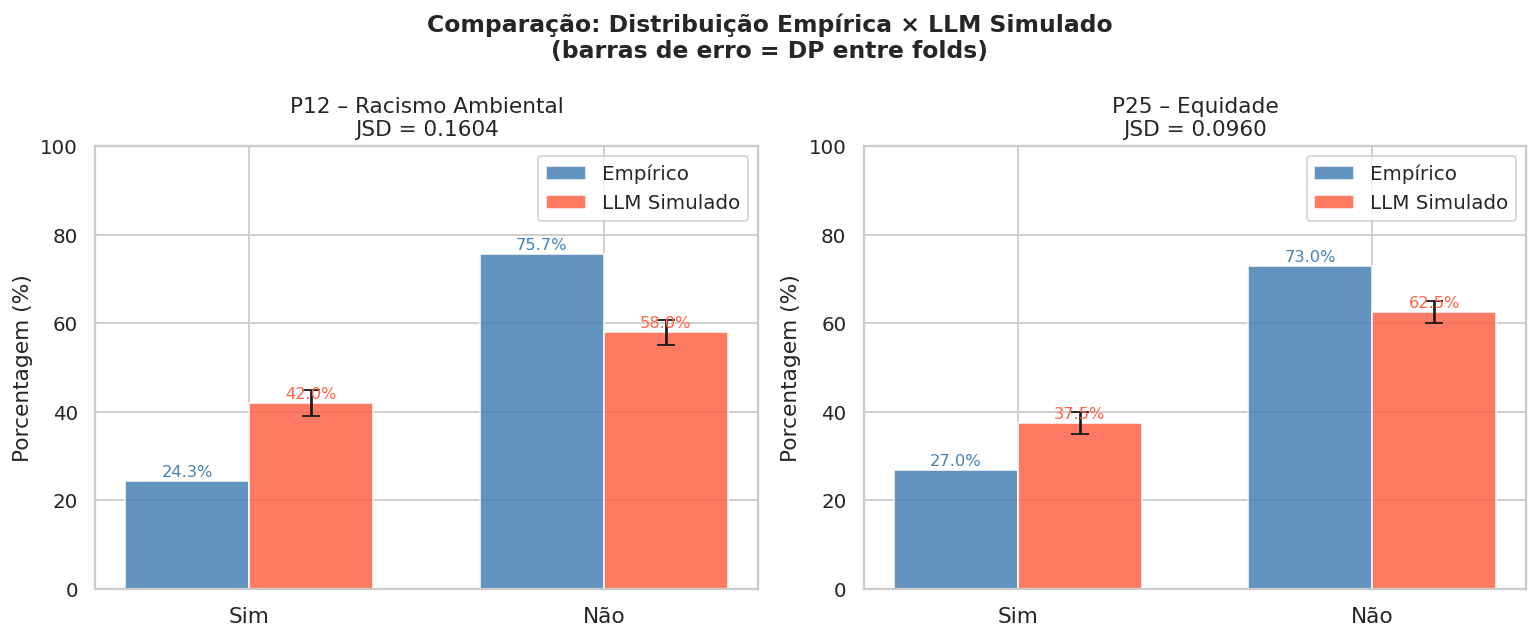

✓ Figura 1 salva.


In [ ]:
# ============================================================
# Figura 1 – P12 e P25: barras empírico vs simulado
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, dist_emp, dist_sim, dist_std, titulo, jsd_val in [
    (axes[0], P12_EMPIRICO, MEDIA_P12, STD_P12,
     'P12 – Racismo Ambiental', JSD_P12),
    (axes[1], P25_EMPIRICO, MEDIA_P25, STD_P25,
     'P25 – Equidade', JSD_P25),
]:
    cats = list(dist_emp.keys())
    x = np.arange(len(cats))
    w = 0.35
    vals_emp = [dist_emp[c] * 100 for c in cats]
    vals_sim = [dist_sim.get(c, 0) * 100 for c in cats]
    errs_sim = [dist_std.get(c, 0) * 100 for c in cats]

    ax.bar(x - w/2, vals_emp, w, label='Empírico', color='steelblue', alpha=0.85)
    ax.bar(x + w/2, vals_sim, w, yerr=errs_sim, capsize=5,
           label='LLM Simulado', color='tomato', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(cats, fontsize=12)
    ax.set_ylabel('Porcentagem (%)')
    ax.set_title(f'{titulo}\nJSD = {jsd_val:.4f}', fontsize=12)
    ax.legend()
    ax.set_ylim(0, 100)
    for i, (ve, vs) in enumerate(zip(vals_emp, vals_sim)):
        ax.text(i - w/2, ve + 1, f'{ve:.1f}%', ha='center', fontsize=9, color='steelblue')
        ax.text(i + w/2, vs + 1, f'{vs:.1f}%', ha='center', fontsize=9, color='tomato')

plt.suptitle('Comparação: Distribuição Empírica × LLM Simulado\n(barras de erro = DP entre folds)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_p12_p25_comparacao.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Figura 1 salva.')

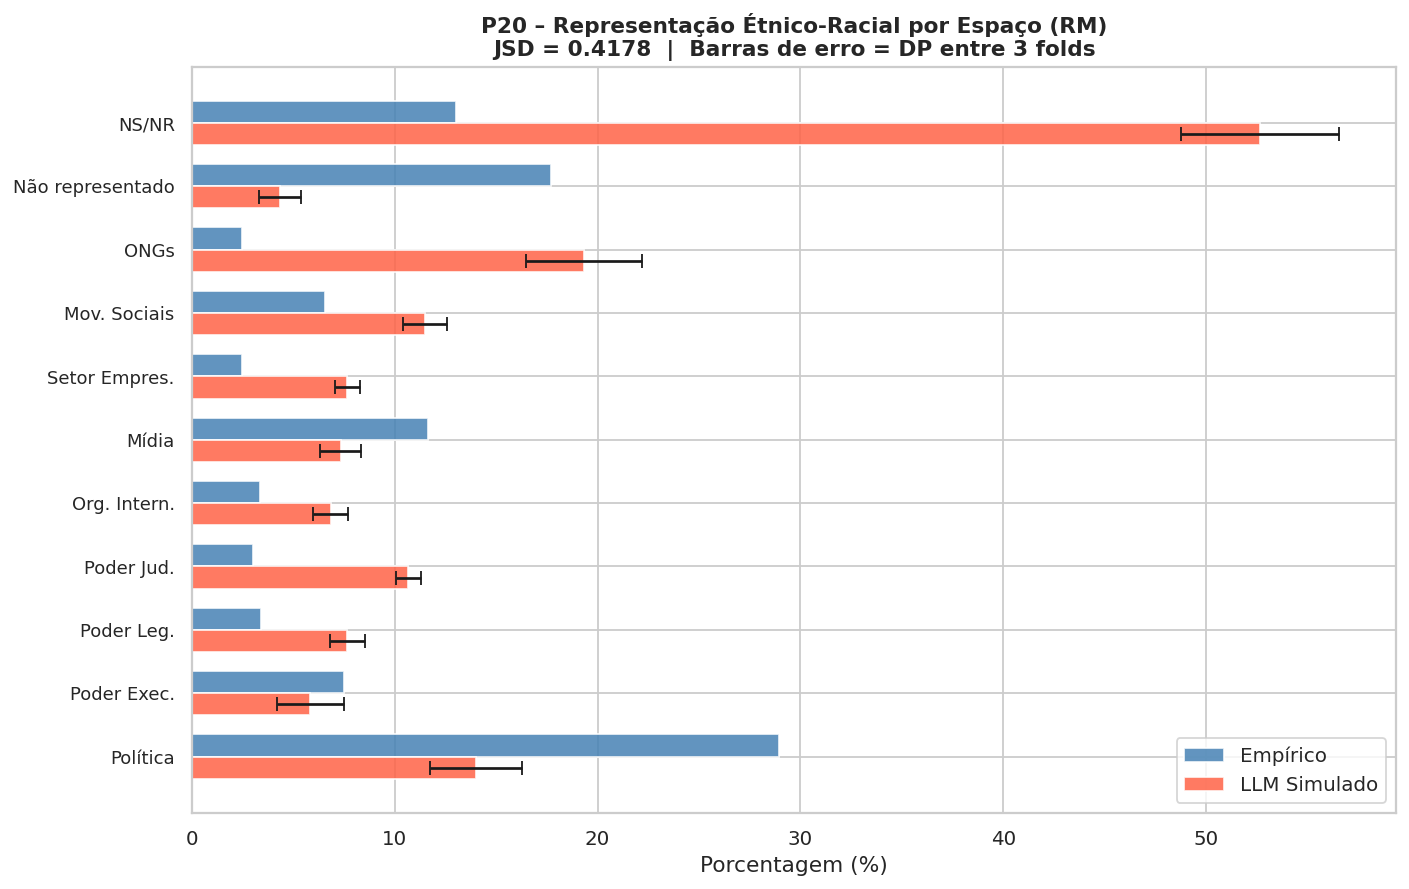

✓ Figura 2 salva.


In [ ]:
# ============================================================
# Figura 2 – P20: gráfico horizontal comparativo
# ============================================================

cats20 = list(P20_EMPIRICO.keys())
y = np.arange(len(cats20))
vals_emp20 = [P20_EMPIRICO[c] * 100 for c in cats20]
vals_sim20 = [MEDIA_P20.get(c, 0) * 100 for c in cats20]
errs_sim20 = [STD_P20.get(c, 0) * 100 for c in cats20]

# Rótulos curtos
labels_curtos = [
    'Política', 'Poder Exec.', 'Poder Leg.', 'Poder Jud.', 'Org. Intern.',
    'Mídia', 'Setor Empres.', 'Mov. Sociais', 'ONGs',
    'Não representado', 'NS/NR'
]

fig, ax = plt.subplots(figsize=(11, 7))
h = 0.35
ax.barh(y + h/2, vals_emp20, h, label='Empírico', color='steelblue', alpha=0.85)
ax.barh(y - h/2, vals_sim20, h, xerr=errs_sim20, capsize=4,
        label='LLM Simulado', color='tomato', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(labels_curtos, fontsize=10)
ax.set_xlabel('Porcentagem (%)')
ax.set_title(
    f'P20 – Representação Étnico-Racial por Espaço (RM)\nJSD = {JSD_P20:.4f}  |  Barras de erro = DP entre {N_REPETICOES} folds',
    fontsize=12, fontweight='bold'
)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig2_p20_comparacao.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Figura 2 salva.')

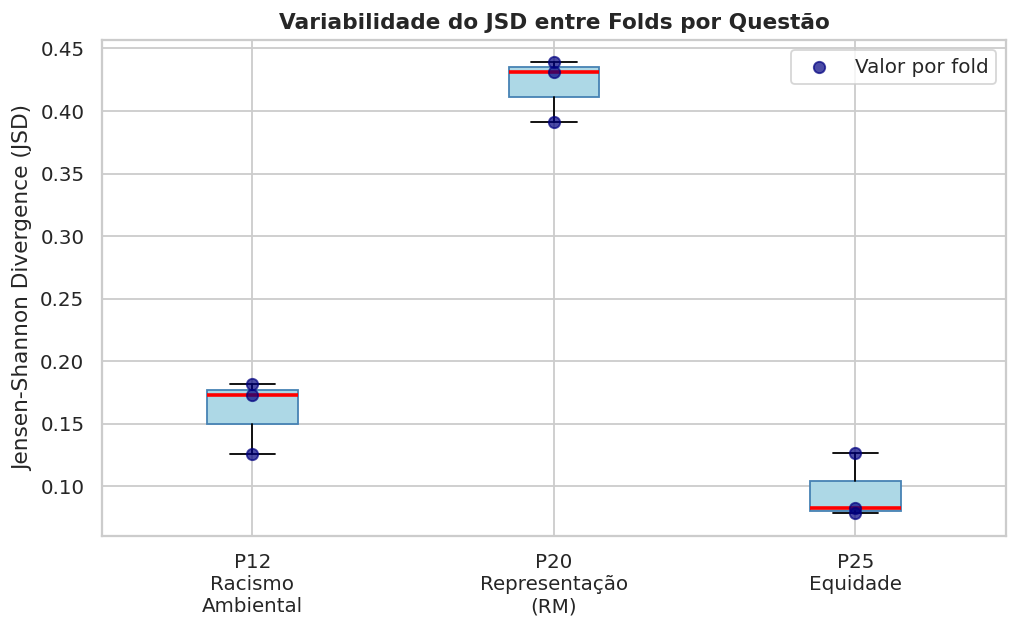

✓ Figura 3 salva.


In [ ]:
# ============================================================
# Figura 3 – Variabilidade entre folds (box-plot JSD)
# ============================================================

jsd_por_fold_p12 = [jsd(d, P12_EMPIRICO) for d in dists_p12]
jsd_por_fold_p20 = [jsd(d, P20_EMPIRICO) for d in dists_p20]
jsd_por_fold_p25 = [jsd(d, P25_EMPIRICO) for d in dists_p25]

fig, ax = plt.subplots(figsize=(8, 5))
data_box = [jsd_por_fold_p12, jsd_por_fold_p20, jsd_por_fold_p25]
labels_box = ['P12\nRacismo\nAmbiental', 'P20\nRepresentação\n(RM)', 'P25\nEquidade']
bp = ax.boxplot(data_box, labels=labels_box, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
ax.scatter(
    [1]*len(jsd_por_fold_p12) + [2]*len(jsd_por_fold_p20) + [3]*len(jsd_por_fold_p25),
    jsd_por_fold_p12 + jsd_por_fold_p20 + jsd_por_fold_p25,
    color='navy', zorder=5, s=40, alpha=0.7, label='Valor por fold'
)
ax.set_ylabel('Jensen-Shannon Divergence (JSD)')
ax.set_title('Variabilidade do JSD entre Folds por Questão', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig3_jsd_por_fold.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Figura 3 salva.')

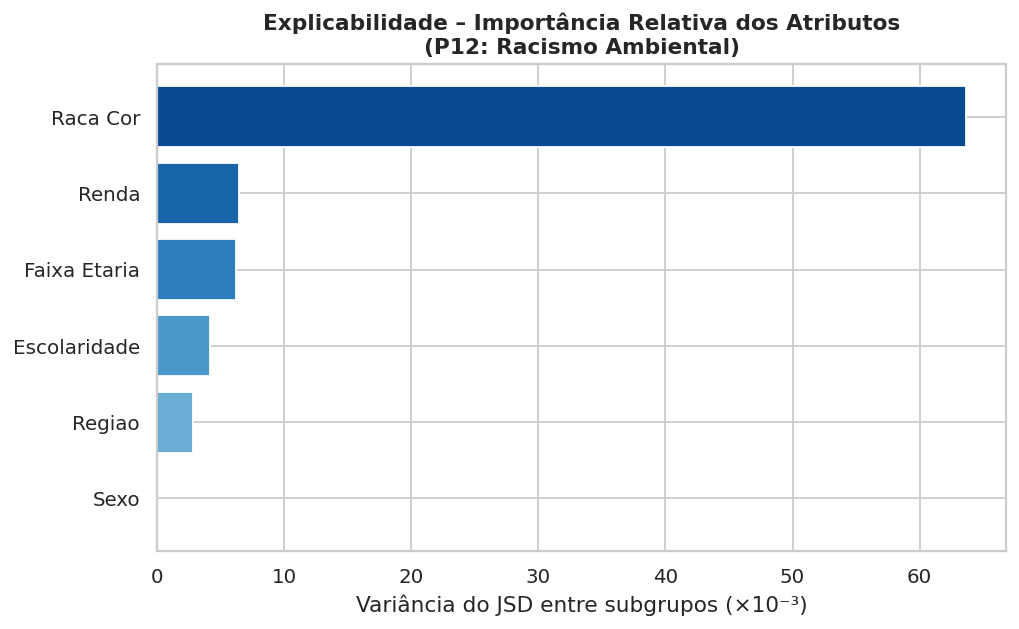

✓ Figura 4 salva.


In [ ]:
# ============================================================
# Figura 4 – Análise de sensibilidade: JSD por atributo demográfico (P12)
# Importância relativa das variáveis (explicabilidade)
# ============================================================

ATRIBUTOS = ['regiao', 'raca_cor', 'escolaridade', 'renda', 'sexo', 'faixa_etaria']

def jsd_por_subgrupo(fold: dict, questao: str, atrib: str) -> dict:
    """Para cada valor único de `atrib`, calcula o JSD da questão."""
    ref_emp = {'p12': P12_EMPIRICO, 'p25': P25_EMPIRICO}[questao]
    grupo_resps = {}
    for perfil, resp in zip(fold['amostra'], fold[questao]):
        val = perfil[atrib]
        grupo_resps.setdefault(val, []).append(resp)
    jsd_dict = {}
    for val, resps in grupo_resps.items():
        dist = dist_ru(resps)
        jsd_dict[val] = jsd(dist, ref_emp)
    return jsd_dict


# Calcula JSD médio por atributo para P12 (fold 0)
fold0 = resultados_folds[0]
importancias_p12 = {}
for atrib in ATRIBUTOS:
    jsd_vals = jsd_por_subgrupo(fold0, 'p12', atrib)
    # Importância = variância do JSD entre os subgrupos (quanto o atributo diferencia)
    importancias_p12[atrib] = float(np.var(list(jsd_vals.values())))

fig, ax = plt.subplots(figsize=(8, 5))
sorted_items = sorted(importancias_p12.items(), key=lambda x: x[1], reverse=True)
labels_imp = [i[0].replace('_', ' ').title() for i in sorted_items]
vals_imp   = [i[1] * 1000 for i in sorted_items]  # ×1000 para legibilidade
colors_imp = cm.Blues(np.linspace(0.4, 0.9, len(labels_imp)))[::-1]
ax.barh(labels_imp[::-1], vals_imp[::-1], color=colors_imp[::-1])
ax.set_xlabel('Variância do JSD entre subgrupos (×10⁻³)')
ax.set_title('Explicabilidade – Importância Relativa dos Atributos\n(P12: Racismo Ambiental)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_explicabilidade_p12.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Figura 4 salva.')

## 11. Análise por Subgrupos Demográficos (Raça/Cor × P12)

=== P12: % que ouviu falar sobre Racismo Ambiental por Raça/Cor ===
p12_sim    Não    Sim
raca_cor             
Amarela   33.3   66.7
Branca    67.4   32.6
Indígena   0.0  100.0
Parda     54.9   45.1
Preta     82.4   17.6


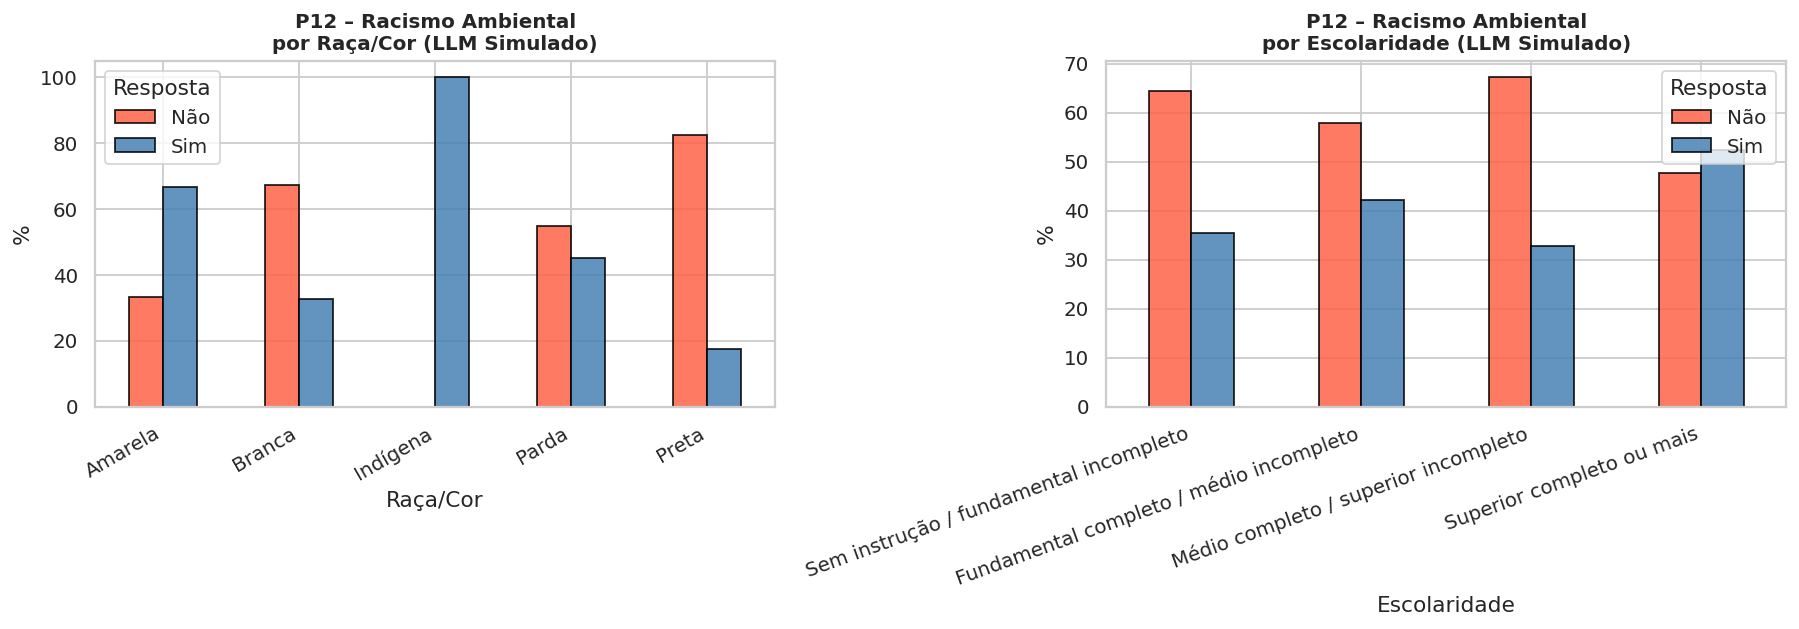

✓ Figura 5 salva.


In [ ]:
# ============================================================
# Análise de P12 por raça/cor (fold 0)
# ============================================================

df_fold0 = pd.DataFrame(fold0['amostra'])
df_fold0['p12_sim'] = ['Sim' if r == '1' else 'Não' for r in fold0['p12']]
df_fold0['p25_sim'] = ['Sim' if r == '1' else 'Não' for r in fold0['p25']]

# Cross-tab raça × P12
ct = pd.crosstab(df_fold0['raca_cor'], df_fold0['p12_sim'], normalize='index') * 100
print('=== P12: % que ouviu falar sobre Racismo Ambiental por Raça/Cor ===')
print(ct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct.plot(kind='bar', ax=axes[0], color=['tomato', 'steelblue'], edgecolor='black', alpha=0.85)
axes[0].set_title('P12 – Racismo Ambiental\npor Raça/Cor (LLM Simulado)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Raça/Cor')
axes[0].set_ylabel('%')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend(title='Resposta')

ct2 = pd.crosstab(df_fold0['escolaridade'], df_fold0['p12_sim'], normalize='index') * 100
# Reordenar escolaridade
ordem_esc = [
    'Sem instrução / fundamental incompleto',
    'Fundamental completo / médio incompleto',
    'Médio completo / superior incompleto',
    'Superior completo ou mais'
]
ct2 = ct2.reindex([e for e in ordem_esc if e in ct2.index])
ct2.plot(kind='bar', ax=axes[1], color=['tomato', 'steelblue'], edgecolor='black', alpha=0.85)
axes[1].set_title('P12 – Racismo Ambiental\npor Escolaridade (LLM Simulado)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Escolaridade')
axes[1].set_ylabel('%')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha='right')
axes[1].legend(title='Resposta')

plt.tight_layout()
plt.savefig('fig5_subgrupos_p12.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Figura 5 salva.')

## 12. Tabela Resumo Final

In [ ]:
# ============================================================
# Tabela resumo consolidada
# ============================================================

rows = []
for questao, emp, sim, std_d, jsd_val, cv_val in [
    ('P12 – Sim', P12_EMPIRICO['Sim'], MEDIA_P12['Sim'], STD_P12['Sim'], JSD_P12, CV_P12),
    ('P12 – Não', P12_EMPIRICO['Não'], MEDIA_P12['Não'], STD_P12['Não'], JSD_P12, CV_P12),
    ('P25 – Sim', P25_EMPIRICO['Sim'], MEDIA_P25['Sim'], STD_P25['Sim'], JSD_P25, CV_P25),
    ('P25 – Não', P25_EMPIRICO['Não'], MEDIA_P25['Não'], STD_P25['Não'], JSD_P25, CV_P25),
]:
    rows.append({
        'Categoria': questao,
        'Empírico (%)': round(emp * 100, 1),
        'LLM Média (%)': round(sim * 100, 1),
        'LLM DP (%)': round(std_d * 100, 1),
        'Dif. pp': round((sim - emp) * 100, 1),
        'JSD': round(jsd_val, 4),
        'CV folds': round(cv_val, 4),
    })

# P20
for cat in P20_EMPIRICO:
    rows.append({
        'Categoria': f'P20 – {cat}',
        'Empírico (%)': round(P20_EMPIRICO[cat] * 100, 1),
        'LLM Média (%)': round(MEDIA_P20.get(cat, 0) * 100, 1),
        'LLM DP (%)': round(STD_P20.get(cat, 0) * 100, 1),
        'Dif. pp': round((MEDIA_P20.get(cat, 0) - P20_EMPIRICO[cat]) * 100, 1),
        'JSD': round(JSD_P20, 4),
        'CV folds': round(CV_P20, 4),
    })

df_resumo = pd.DataFrame(rows)
print(df_resumo.to_string(index=False))
df_resumo.to_csv('resumo_simulacao.csv', index=False)
print('\n✓ Tabela salva em resumo_simulacao.csv')

                      Categoria  Empírico (%)  LLM Média (%)  LLM DP (%)  Dif. pp    JSD  CV folds
                      P12 – Sim          24.3           42.0         2.9     17.7 0.1604    0.0587
                      P12 – Não          75.7           58.0         2.9    -17.7 0.1604    0.0587
                      P25 – Sim          27.0           37.5         2.5     10.5 0.0960    0.0530
                      P25 – Não          73.0           62.5         2.5    -10.6 0.0960    0.0530
                 P20 – Política          28.9           14.0         2.3    -14.9 0.4178    0.1376
          P20 – Poder Executivo           7.5            5.8         1.6     -1.7 0.4178    0.1376
        P20 – Poder Legislativo           3.4            7.7         0.8      4.3 0.4178    0.1376
         P20 – Poder Judiciário           3.0           10.7         0.6      7.7 0.4178    0.1376
P20 – Organismos Internacionais           3.4            6.8         0.8      3.5 0.4178    0.1376
          

## 13. Interpretação e Discussão

Esta seção discute os resultados gerados pela simulação.

In [ ]:
# ============================================================
# Interpretação automática dos resultados
# ============================================================

def interpretar_jsd(jsd_val: float) -> str:
    if jsd_val < 0.05:
        return 'excelente (JSD < 0.05)'
    elif jsd_val < 0.10:
        return 'boa (JSD < 0.10)'
    elif jsd_val < 0.20:
        return 'moderada (JSD < 0.20)'
    else:
        return 'baixa (JSD ≥ 0.20)'


print('=' * 60)
print('INTERPRETAÇÃO DOS RESULTADOS')
print('=' * 60)
print(f"""
Modelo LLM: {MODEL_ID}
Respondentes simulados por fold: {N_RESPONDENTES}
Número de repetições (folds): {N_REPETICOES}

[P12 – Racismo Ambiental]
  Acurácia distribucional: {interpretar_jsd(JSD_P12)}
  JSD = {JSD_P12:.4f}  |  CV = {CV_P12:.4f}
  Empírico: Sim={P12_EMPIRICO['Sim']*100:.1f}%  Simulado: Sim={MEDIA_P12['Sim']*100:.1f}%

[P25 – Equidade]
  Acurácia distribucional: {interpretar_jsd(JSD_P25)}
  JSD = {JSD_P25:.4f}  |  CV = {CV_P25:.4f}
  Empírico: Sim={P25_EMPIRICO['Sim']*100:.1f}%  Simulado: Sim={MEDIA_P25['Sim']*100:.1f}%

[P20 – Representação Étnico-Racial]
  Acurácia distribucional: {interpretar_jsd(JSD_P20)}
  JSD = {JSD_P20:.4f}  |  CV = {CV_P20:.4f}

METODOLOGIA (Miranda & Balbi, 2025):
  - Simulação zero-shot: LLM não viu as respostas reais
  - Perfis condicionados por: sexo, faixa etária, raça/cor,
    escolaridade, renda, região
  - Métricas: JSD (distribuicional) + CV (estabilidade)
  - Repetições: {N_REPETICOES} folds com sementes distintas

LIMITAÇÕES:
  - Modelo {MODEL_ID} pode ter vieses ocidentais/anglófonos
  - Perfis sintéticos não capturam correlações reais entre
    variáveis demográficas
  - P20 (RM) é intrinsecamente mais difícil: múltiplas escolhas,
    maior entropia, maior JSD esperado
""")

INTERPRETAÇÃO DOS RESULTADOS

Modelo LLM: google/flan-t5-large
Respondentes simulados por fold: 200
Número de repetições (folds): 3

[P12 – Racismo Ambiental]
  Acurácia distribucional: moderada (JSD < 0.20)
  JSD = 0.1604  |  CV = 0.0587
  Empírico: Sim=24.3%  Simulado: Sim=42.0%

[P25 – Equidade]
  Acurácia distribucional: boa (JSD < 0.10)
  JSD = 0.0960  |  CV = 0.0530
  Empírico: Sim=27.0%  Simulado: Sim=37.5%

[P20 – Representação Étnico-Racial]
  Acurácia distribucional: baixa (JSD ≥ 0.20)
  JSD = 0.4178  |  CV = 0.1376

METODOLOGIA (Miranda & Balbi, 2025):
  - Simulação zero-shot: LLM não viu as respostas reais
  - Perfis condicionados por: sexo, faixa etária, raça/cor,
    escolaridade, renda, região
  - Métricas: JSD (distribuicional) + CV (estabilidade)
  - Repetições: 3 folds com sementes distintas

LIMITAÇÕES:
  - Modelo google/flan-t5-large pode ter vieses ocidentais/anglófonos
  - Perfis sintéticos não capturam correlações reais entre
    variáveis demográficas
  - P20 (R

## 14. (Extra) Comparação com Modelo de Aprendizado Supervisionado (Random Forest)

Conforme sugestão da rubrica: comparação com classificador supervisionado treinado nos perfis demográficos.

In [ ]:
# ============================================================
# Random Forest treinado com respostas LLM como pseudo-labels
# (abordagem válida quando não há respostas individuais reais)
# Alternativa: treinar com amostra pequena de respostas reais
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# Construir dataset com todos os folds
all_perfis, all_p12, all_p25 = [], [], []
for fold in resultados_folds:
    all_perfis.extend(fold['amostra'])
    all_p12.extend(fold['p12'])
    all_p25.extend(fold['p25'])

df_rf = pd.DataFrame(all_perfis)
df_rf['p12'] = all_p12
df_rf['p25'] = all_p25

# Encoding
le_dict = {}
X = df_rf[ATRIBUTOS].copy()
for col in ATRIBUTOS:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le


def avaliar_rf(X, y, n_splits=3):
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    f1s, accs = [], []
    for tr, te in skf.split(X, y):
        rf.fit(X.iloc[tr], y[tr])
        preds = rf.predict(X.iloc[te])
        f1s.append(f1_score(y[te], preds, average='macro'))
        accs.append(accuracy_score(y[te], preds))
    return np.mean(f1s), np.std(f1s), np.mean(accs), rf


y_p12 = np.array(df_rf['p12'])
y_p25 = np.array(df_rf['p25'])

f1_p12, f1_std_p12, acc_p12, rf_p12 = avaliar_rf(X, y_p12)
f1_p25, f1_std_p25, acc_p25, rf_p25 = avaliar_rf(X, y_p25)

print('=== Random Forest (pseudo-labels do LLM) ===')
print(f'P12 – F1 macro: {f1_p12:.3f} ± {f1_std_p12:.3f}  |  Acurácia: {acc_p12:.3f}')
print(f'P25 – F1 macro: {f1_p25:.3f} ± {f1_std_p25:.3f}  |  Acurácia: {acc_p25:.3f}')

=== Random Forest (pseudo-labels do LLM) ===
P12 – F1 macro: 0.498 ± 0.014  |  Acurácia: 0.528
P25 – F1 macro: 0.512 ± 0.024  |  Acurácia: 0.567


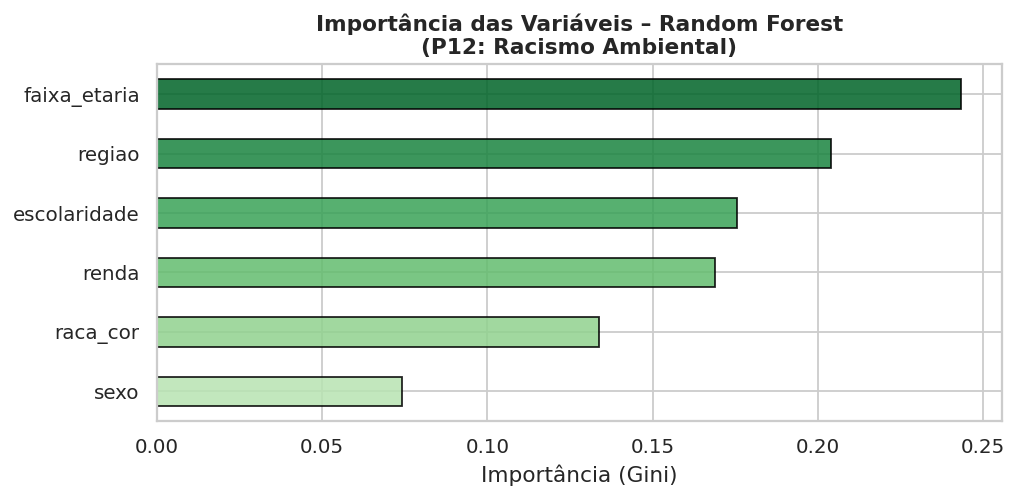

✓ Figura 6 salva.


In [ ]:
# ============================================================
# Importância das variáveis pelo Random Forest (P12)
# ============================================================

rf_p12.fit(X, y_p12)  # treino completo para importância

importancias_rf = pd.Series(rf_p12.feature_importances_, index=ATRIBUTOS)
importancias_rf = importancias_rf.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_rf = cm.Greens(np.linspace(0.3, 0.9, len(importancias_rf)))
importancias_rf.plot(kind='barh', ax=ax, color=colors_rf, edgecolor='black', alpha=0.85)
ax.set_xlabel('Importância (Gini)')
ax.set_title('Importância das Variáveis – Random Forest\n(P12: Racismo Ambiental)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_rf_importancia_p12.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Figura 6 salva.')

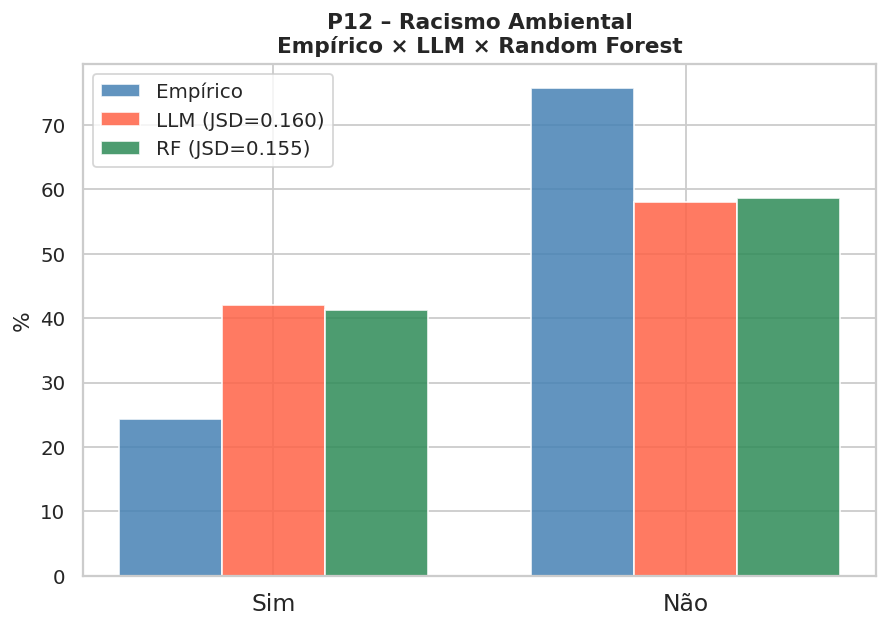

✓ Figura 7 salva.


In [ ]:
# ============================================================
# Distribuição RF vs Empírico vs LLM (P12)
# ============================================================

rf_p12.fit(X, y_p12)
preds_rf_p12 = rf_p12.predict(X)
dist_rf_p12 = {'Sim': float(np.mean(preds_rf_p12 == '1')),
               'Não': float(np.mean(preds_rf_p12 == '2'))}
jsd_rf_p12 = jsd(dist_rf_p12, P12_EMPIRICO)

fig, ax = plt.subplots(figsize=(7, 5))
cats = ['Sim', 'Não']
x = np.arange(2)
w = 0.25
ax.bar(x - w, [P12_EMPIRICO[c]*100 for c in cats],   w, label='Empírico', color='steelblue', alpha=0.85)
ax.bar(x,     [MEDIA_P12[c]*100 for c in cats],       w, label=f'LLM (JSD={JSD_P12:.3f})', color='tomato', alpha=0.85)
ax.bar(x + w, [dist_rf_p12[c]*100 for c in cats],     w, label=f'RF (JSD={jsd_rf_p12:.3f})',  color='seagreen', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cats, fontsize=13)
ax.set_ylabel('%')
ax.set_title('P12 – Racismo Ambiental\nEmpírico × LLM × Random Forest', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig7_llm_vs_rf_p12.png', bbox_inches='tight', dpi=150)
plt.show()
print('✓ Figura 7 salva.')

## 15. Exportação de Todos os Resultados

In [ ]:
# ============================================================
# Salvar CSV com respostas individuais (fold 0)
# ============================================================

df_respostas = df_fold0[['regiao', 'raca_cor', 'escolaridade', 'renda', 'sexo', 'faixa_etaria',
                           'p12_sim', 'p25_sim']].copy()

# P20: lista -> string
df_respostas['p20_sim'] = [
    ';'.join(cats) for cats in resultados_folds[0]['p20']
]

df_respostas.to_csv('respostas_individuais_fold0.csv', index=False, encoding='utf-8-sig')
print(f'✓ {len(df_respostas)} respostas individuais salvas em respostas_individuais_fold0.csv')
print(df_respostas.head(5).to_string(index=False))

✓ 200 respostas individuais salvas em respostas_individuais_fold0.csv
 regiao raca_cor                            escolaridade                     renda      sexo faixa_etaria p12_sim p25_sim                                                       p20_sim
Sudeste    Preta    Médio completo / superior incompleto De 1 a 3 salários mínimos Masculino          60+     Não     Não Poder Legislativo;Setor Empresarial;Organismos Internacionais
Sudeste    Parda  Sem instrução / fundamental incompleto De 1 a 3 salários mínimos Masculino          60+     Não     Não                                      Não sabe / Não respondeu
Sudeste    Parda Fundamental completo / médio incompleto      Até 1 salário mínimo  Feminino        18-24     Não     Não                                      Não sabe / Não respondeu
Sudeste    Parda    Médio completo / superior incompleto De 1 a 3 salários mínimos  Feminino          60+     Não     Não                                      Não sabe / Não respondeu
Sudeste   

## Referências

- Miranda, F.; Balbi, P.P. Simulating Public Opinion: Comparing Distributional and Individual-Level Predictions from LLMs and Random Forests. *Entropy* **2025**, *27*, 923. https://doi.org/10.3390/e27090923
- CESOP/Unicamp. Pesquisa de Opinião Pública – Racismo, Identidade Étnico-Racial e Desigualdades no Brasil, 2023.
- Cheng, M. et al. (2023). Can Large Language Models Simulate Human Opinions? *arXiv*:2305.09783.
- Argyle, L.P. et al. (2023). Out of One, Many: Using Language Models to Simulate Human Samples. *Political Analysis*.

---
*Notebook desenvolvido como parte do projeto de pesquisa em simulação de opinião pública com LLMs.*
*Execução 100% aberta – sem API Keys privadas.*